# Score Divergence 🔀

This notebook serves to visualize the divergence between similiar and different scences.

## Experiment 1: Indoor: Same vs. Different

In this experiment, we will compare the divergence between one indoor scene vs another. These were taken of different rooms and vary in object movement and lighting.

We should ignore pairwise, as we are comparing the divergence between the two similar / difference scenes. A pairwise comparison would always have large divergence as it compares each frame to every other frame.

In [1]:
from utils.csvs import TrainSimilarityScores

In [2]:
path = '2_fov/1_office/train_similarity_scores'
office = TrainSimilarityScores(f'{path}/*.csv', f'{path}/pairwise*.csv')
office.summary_table()

Skipping 2_fov/1_office/train_similarity_scores/pairwise_portrait_270_degree_S9.csv
Skipping 2_fov/1_office/train_similarity_scores/pairwise_landscape_90_degree_PXL3.csv
Skipping 2_fov/1_office/train_similarity_scores/pairwise_landscape_180_degree_iPhone13.csv


Metric | Average | Minimum | Maximum | St. Dev. | St. Error
---|---|---|---|---|---
KLD | 0.233882120 | 0.000107131 | 2.818453591 | 0.689592367 | 0.014817100
Cramer | 0.012941241 | 0.001897134 | 0.048079530 | 0.013853145 | 0.000297659
Bhattacharyya | 0.989073394 | 0.931789904 | 0.999973200 | 0.021463066 | 0.000461172

In [3]:
path = '2_fov/2_vacuum/train_similarity_scores'
vacuum = TrainSimilarityScores(f'{path}/*.csv', exclude_pattern=f'{path}/pairwise*.csv')
vacuum.summary_table()

Skipping 2_fov/2_vacuum/train_similarity_scores/pairwise_portrait_180_degree_S9.csv
Skipping 2_fov/2_vacuum/train_similarity_scores/pairwise_landscape_90_degree_iPhone13.csv


Metric | Average | Minimum | Maximum | St. Dev. | St. Error
---|---|---|---|---|---
KLD | 0.431138060 | 0.000010972 | 3.145404412 | 0.882761059 | 0.032852965
Cramer | 0.018204171 | 0.000574544 | 0.050740716 | 0.018905616 | 0.000703594
Bhattacharyya | 0.980024903 | 0.925635123 | 0.999997257 | 0.026790111 | 0.000997025

In [4]:
different = TrainSimilarityScores(f'2_fov/3_compare_1_2/train_similarity_scores/*.csv')
different.summary_table()

Metric | Average | Minimum | Maximum | St. Dev. | St. Error
---|---|---|---|---|---
KLD | 0.386857644 | 0.000064828 | 3.478288905 | 0.711497794 | 0.015287777
Cramer | 0.023505048 | 0.001505514 | 0.053275798 | 0.011092368 | 0.000238339
Bhattacharyya | 0.980914652 | 0.917204477 | 0.999983764 | 0.019966452 | 0.000429014

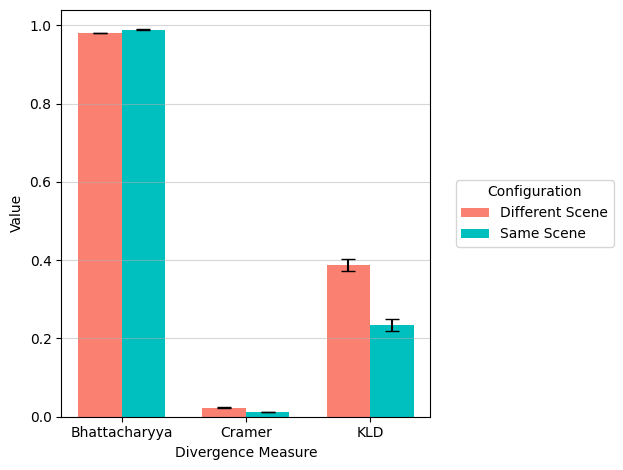

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Sample data (replace with your actual data)
data = {
    'Divergence Measure': ['Bhattacharyya', 'Cramer', 'KLD'],
    'Different Scene': [0.980914652, 0.023505048, 0.386857644],
    'Same Scene': [0.989073394, 0.012941241, 0.233882120],
    'Different Scene Error': [0.000429014, 0.000238339, 0.015287777],
    'Same Scene Error': [0.000461172, 0.000297659, 0.014817100]
}
df = pd.DataFrame(data)

# Set up the plot
fig, ax = plt.subplots()
width = 0.35  # Width of the bars
x = np.arange(len(df['Divergence Measure']))

# Plot bars with error bars
bars1 = ax.bar(x - width/2, df['Different Scene'], width, label='Different Scene', color='salmon', yerr=df['Different Scene Error'], capsize=5)
bars2 = ax.bar(x + width/2, df['Same Scene'], width, label='Same Scene', color='c', yerr=df['Same Scene Error'], capsize=5)
# bars3

# Set labels, title, and legend
ax.set_xlabel('Divergence Measure')
ax.set_ylabel('Value')
ax.set_xticks(x)
ax.set_xticklabels(df['Divergence Measure'])
ax.legend(title='Configuration', bbox_to_anchor=(1.05, 0.5), loc='center left')

# Add gridlines
plt.grid(True, axis='y', alpha=0.5)

# Show the plot
plt.tight_layout()
plt.show()